# Imports and Load Data


In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## Explore Data


In [25]:
df = pd.read_csv('/content/AI-Eng-Data-Challenge.csv')
df

,claim_id,member_name,service,submission_date,provider_id,claimstatus,auto_approved_claim,clinical_reviewer,member_id,reason
0,001d0f43-33a2-4add-b8a8-2b32b73ef318,Sophie,Vaccination,2/24/2024 14:26,1008,Approved,False,NaN,MBR-1953,Full coverage approved: Routine annual immuniz...
1,003031d6-cf95-4c0c-b0f2-06c89dff726f,Harper,Lab Test,11/26/2023 14:26,1006,Approved,False,NaN,MBR-8260,Approved: Laboratory panel (3 units) is medica...
2,003fae46-1e76-4aba-8670-95d9dabf1848,Gunther,Vaccination,7/17/2024 14:26,1002,Approved,False,NaN,MBR-1854,Approved: Multi-dose viral series (4 units) fu...
3,004389e2-75b9-484d-ab9b-cd9b00e8af4f,Thomas,X-ray,4/25/2024 14:26,1003,Denied,False,NaN,MBR-7814,Denied: Duplicate service submission; initial ...
4,004e13f1-d8ed-4e32-8d3d-886764f7835b,Roxy,Dental Cleaning,9/25/2023 14:26,1019,Denied,False,NaN,MBR-4027,Denied: Frequency limit exceeded; last dental ...
...,...,...,...,...,...,...,...,...,...,...
1017,5640012e-ce13-401f-b77a-832a9afc9c3d,Cooper,X-ray,1/8/2024 14:26,1014,Denied,False,NaN,MBR-7513,Policy requirements not met.
1018,564eaadf-53a5-4fac-8cec-38a71ff32198,Missy,Vaccination,3/24/2024 14:26,1016,Approved,False,NaN,MBR-5837,Meets all policy requirements.
1019,565ae44c-f90f-421f-8909-4e800e4f1b8a,Nike,Check-up,1/2/2024 14:26,1007,Approved,False,NaN,MBR-1197,Meets all policy requirements.
1020,56697a32-ae59-4c0b-b3f6-47d330bd8e0a,Lizzy,Lab Test,4/4/2024 14:26,1003,Approved,False,NaN,MBR-7824,Meets all policy requirements.


## Initial Questions:

#### Cleaning
- [x] Are there Missing values?
- [x] Duplicate claims?


#### Analytics & Understanding:
- [x] What is the total number of claims Approved / Denied / Pending?
- [x] Overall distribution (amount of claims) of services, providers, and members?
- [x] Trend of claims of time?
- How many claims are auto approved and how many are not?

#### Metrics & NLP
- [x] What is the approval rate and denial rate for each of the following categories; Service, Member_id, Provider_id.
- What is the word frequency in the reasoning approved and denied?
- what is the accuracy, false positives and false negatives of the auto approval?




In [61]:
#lets check the missing values and for duplicate records.
print(df.shape)

#Convert date to usable object
df['submission_date'] = pd.to_datetime(df['submission_date'])


missing = df.isna().sum()
full_dupes = df.duplicated().sum()
id_dupes = df['claim_id'].duplicated().sum()

print("Missing Values:\n", missing)
print("Full Row Duplicate Values: ", full_dupes)
print("ID Duplicate Values: ", id_dupes)
#Data looks very clean, missing reviewers does not cause an issue here.

(1022, 10)
Missing Values:
 claim_id                 0
member_name              0
service                  0
submission_date          0
provider_id              0
claimstatus              0
auto_approved_claim      0
clinical_reviewer      715
member_id                0
reason                   0
dtype: int64
Full Row Duplicate Values:  0
ID Duplicate Values:  0


In [109]:
from matplotlib.colors import Normalize
#get an understanding of claim counts and stats
totals = df['claimstatus'].value_counts().reset_index()
totals['percent_count'] = (totals['count']/totals['count'].sum()).round(3)
display(totals)

#distribution of types of service
service_dist = df.service.value_counts().reset_index()
service_dist['percent_count'] = (service_dist['count']/service_dist['count'].sum()).round(3)

#approval, denial and pending rate
service_stat = df.groupby('service')['claimstatus'].value_counts(normalize=True).unstack()
service_stat = service_stat.reset_index()

service_summary = service_dist.join(service_stat.set_index('service'), on='service')
service_summary = service_summary.fillna(0)

display(service_summary)

,claimstatus,count,percent_count
0,Approved,705,0.690
1,Denied,275,0.269
2,Pending,42,0.041


,service,count,percent_count,Approved,Denied,Pending
0,Check-up,295,0.289,0.993220,0.006780,0.000000
1,X-ray,198,0.194,0.363636,0.580808,0.055556
2,Vaccination,168,0.164,0.744048,0.202381,0.053571
3,Dental Cleaning,158,0.155,0.481013,0.462025,0.056962
4,Lab Test,107,0.105,0.775701,0.130841,0.093458
5,Surgery,96,0.094,0.583333,0.385417,0.031250


In [ ]:
#Visualization:
#pie chart for status distribution
#bar chart 3 classes for each category. approved, denied, pending. bar heights will be %.



In [120]:
#top 5 most common providers
provider_dist = df.provider_id.value_counts().reset_index()
provider_stat = df.groupby('provider_id')['claimstatus'].value_counts(normalize=True).unstack().reset_index()
provider_summary = provider_dist.join(provider_stat.set_index('provider_id'), on='provider_id')
provider_summary = provider_summary.fillna(0)
display(provider_summary.head())

#top 5 members with highest claim count
member_dist = df.member_id.value_counts().reset_index()
member_stat = df.groupby('member_id')['claimstatus'].value_counts(normalize=True).unstack().reset_index()
member_summary = member_dist.join(member_stat.set_index('member_id'), on='member_id')
member_summary = member_summary.fillna(0)
display(member_summary.head())

,provider_id,count,Approved,Denied,Pending
0,1008,56,0.660714,0.303571,0.035714
1,1006,56,0.821429,0.160714,0.017857
2,1005,56,0.732143,0.232143,0.035714
3,1013,56,0.660714,0.321429,0.017857
4,1018,54,0.648148,0.296296,0.055556


,member_id,count,Approved,Denied,Pending
0,MBR-2366,16,0.750000,0.250000,0.0
1,MBR-3458,15,0.666667,0.333333,0.0
2,MBR-5992,13,0.615385,0.384615,0.0
3,MBR-4079,13,1.000000,0.000000,0.0
4,MBR-4027,12,0.500000,0.500000,0.0


## Claims Trend

2023-08-20 14:26:00 2024-08-19 14:26:00


<Axes: title={'center': 'Claims Over Time'}, xlabel='year_month'>

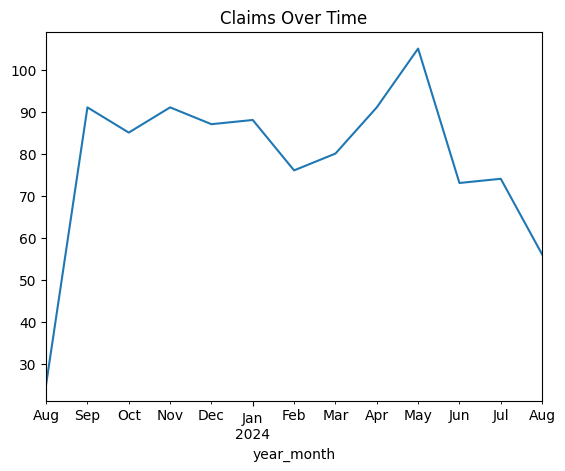

In [86]:
#looking through aug-2023 to aug-2024
print(df.submission_date.min(), df.submission_date.max())
df['year_month'] = df.submission_date.dt.to_period('M')
monthly_counts = (df.groupby('year_month').size())
monthly_counts.plot(title='Claims Over Time', x='year_month', y='claims count', kind='line')